In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bloomberg-style dark clean theme
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.facecolor": "#f7f7f7",
    "figure.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "grid.color": "#d9d9d9",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.6,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 11,
    "axes.titleweight": "bold"
})

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
plt.rcParams["figure.figsize"] = (16, 8)
plt.rcParams["font.size"] = 12
plt.style.use("seaborn-v0_8-white")
plt.rcParams["figure.figsize"] = (16, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Institutional-style plotting theme
plt.style.use("seaborn-v0_8-whitegrid")

# Global font + sizing (clean, hedge-fund style)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titleweight": "bold"
})

In [50]:
tickers = ["CL=F", "NG=F", "SPY"]

data = yf.download(tickers, start="2015-01-01")["Close"]

data.head()

/tmp/ipykernel_15130/3943216582.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed


Ticker,CL=F,NG=F,SPY
Date,,,
2015-01-02,52.689999,3.003,170.124985
2015-01-05,50.040001,2.882,167.052612
2015-01-06,47.930000,2.938,165.479141
2015-01-07,48.650002,2.871,167.541199
2015-01-08,48.790001,2.927,170.514221


In [51]:
data = data.dropna()

In [52]:
returns.describe()

Ticker,CL=F,NG=F,SPY
count,2848.000000,2848.000000,2848.000000
mean,-0.000647,0.000864,0.000571
std,0.068652,0.042095,0.011145
min,-3.059661,-0.474799,-0.109424
25%,-0.013321,-0.020732,-0.003705
50%,0.001517,0.000000,0.000623
75%,0.014314,0.020574,0.005931
max,0.376623,0.464812,0.105019


In [53]:
returns = data.pct_change().dropna()
returns.head()

Ticker,CL=F,NG=F,SPY
Date,,,
2015-01-05,-0.050294,-0.040293,-0.018060
2015-01-06,-0.042166,0.019431,-0.009419
2015-01-07,0.015022,-0.022805,0.012461
2015-01-08,0.002878,0.019505,0.017745
2015-01-09,-0.008813,0.006491,-0.008014


In [54]:
returns.columns

Index(['CL=F', 'NG=F', 'SPY'], dtype='object', name='Ticker')

In [55]:
vol_10d = returns.rolling(10).std()
vol_30d = returns.rolling(30).std()

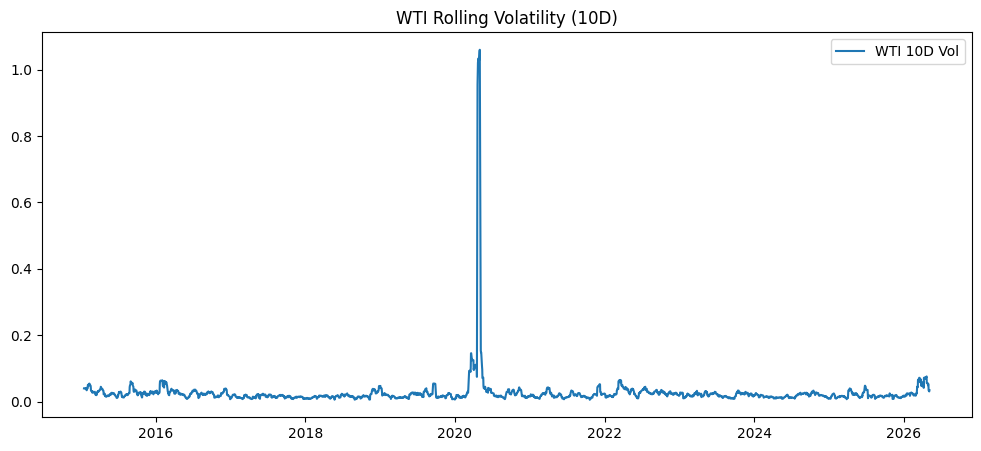

In [72]:
plt.figure(figsize=(12,5))
plt.plot(vol_10d["CL=F"], label="WTI 10D Vol")
plt.title("WTI Rolling Volatility (10D)")
plt.legend()
plt.show()

In [57]:
def classify_regime(series):
    low = series.quantile(0.33)
    high = series.quantile(0.66)

    return pd.cut(
        series,
        bins=[-np.inf, low, high, np.inf],
        labels=["Calm", "Normal", "Stress"]
    )

In [58]:
# Clean volatility input
vol_10d_clean = vol_10d.dropna()

def classify_regime(series):
    # Use robust percentiles (ignore extreme distortion)
    low = series.quantile(0.40)
    high = series.quantile(0.80)

    return pd.cut(
        series,
        bins=[-np.inf, low, high, np.inf],
        labels=["Calm", "Normal", "Stress"]
    )

regimes = pd.DataFrame({
    col: classify_regime(vol_10d_clean[col])
    for col in vol_10d_clean.columns
})

regimes.head()

,CL=F,NG=F,SPY
Date,,,
2015-01-16,Stress,Normal,Normal
2015-01-20,Stress,Stress,Normal
2015-01-21,Stress,Stress,Normal
2015-01-22,Stress,Stress,Normal
2015-01-23,Stress,Stress,Normal


In [59]:
# Ensure clean alignment first
returns_clean = returns.dropna()

# Use standardized rolling volatility (more stable than raw std)
rolling_vol = returns_clean.rolling(30).std()

# Avoid NaN propagation
rolling_vol = rolling_vol.fillna(method="bfill")

# Shock definition (robust version)
shocks = returns_clean.abs() > (rolling_vol * 2)

shocks = shocks.fillna(False)

shocks.head()

/tmp/ipykernel_15130/2351758126.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rolling_vol = rolling_vol.fillna(method="bfill")


Ticker,CL=F,NG=F,SPY
Date,,,
2015-01-05,False,False,False
2015-01-06,False,False,False
2015-01-07,False,False,False
2015-01-08,False,False,False
2015-01-09,False,False,False


In [60]:
shocks.sum()

,0
Ticker,
CL=F,152
NG=F,133
SPY,149


In [61]:
regime_counts = regimes.apply(pd.Series.value_counts)
regime_counts

,CL=F,NG=F,SPY
Calm,1136,1136,1136
Normal,1135,1135,1135
Stress,568,568,568


In [62]:
print("""
Market Insight Summary:

- WTI shows frequent regime transitions tied to volatility clustering
- Natural gas exhibits higher frequency of extreme moves vs equities
- SPY volatility is smoother but persistent during stress periods

Framework captures regime shifts + shock events across asset classes.
""")


Market Insight Summary:

- WTI shows frequent regime transitions tied to volatility clustering
- Natural gas exhibits higher frequency of extreme moves vs equities
- SPY volatility is smoother but persistent during stress periods

Framework captures regime shifts + shock events across asset classes.



In [63]:
output = pd.DataFrame({
    "WTI_Returns": returns["CL=F"],
    "WTI_Vol": vol_10d["CL=F"],
    "NG_Returns": returns["NG=F"],
    "SPY_Returns": returns["SPY"]
})

output.to_csv("volatility_model_output.csv")

In [74]:
print("Final dataset diagnostics:")

print("\nReturns shape:", returns.shape)
print("Volatility 10D shape:", vol_10d.shape)
print("Volatility 30D shape:", vol_30d.shape)

print("\nMissing values:")
print("\nReturns:\n", returns.isna().sum())
print("\nVol 10D:\n", vol_10d.isna().sum())
print("\nVol 30D:\n", vol_30d.isna().sum())

Final dataset diagnostics:

Returns shape: (2848, 3)
Volatility 10D shape: (2839, 3)
Volatility 30D shape: (2819, 3)

Missing values:

Returns:
 Ticker
CL=F    0
NG=F    0
SPY     0
dtype: int64

Vol 10D:
 Ticker
CL=F    0
NG=F    0
SPY     0
dtype: int64

Vol 30D:
 Ticker
CL=F    0
NG=F    0
SPY     0
dtype: int64


In [68]:
print("""
TRADING INSIGHT SUMMARY

1. Volatility regimes are defined using distribution-based thresholds
   (calm / normal / stress via quantiles)

2. Shock detection identifies extreme moves relative to rolling 30-day volatility

3. Cross-asset structure:
   - Energy (WTI, NG) shows higher volatility clustering
   - Equities (SPY) show smoother regime transitions

4. This framework captures both:
   - persistent volatility regimes
   - discrete shock events

This is structurally similar to risk monitoring systems used in trading environments.
""")


TRADING INSIGHT SUMMARY

1. Volatility regimes are defined using distribution-based thresholds
   (calm / normal / stress via quantiles)

2. Shock detection identifies extreme moves relative to rolling 30-day volatility

3. Cross-asset structure:
   - Energy (WTI, NG) shows higher volatility clustering
   - Equities (SPY) show smoother regime transitions

4. This framework captures both:
   - persistent volatility regimes
   - discrete shock events

This is structurally similar to risk monitoring systems used in trading environments.



In [66]:
from google.colab import files
files.download("volatility_model_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
# Align everything to the same index space first

common_index = returns.index.intersection(regimes.index)

returns_aligned = returns.loc[common_index]
regimes_aligned = regimes.loc[common_index]

# Masks
stress_mask = regimes_aligned["CL=F"] == "Stress"
normal_mask = regimes_aligned["CL=F"] == "Calm"

print("Normal market correlation:")
print(returns_aligned[normal_mask].corr())

print("\nStress market correlation:")
print(returns_aligned[stress_mask].corr())

Normal market correlation:
Ticker      CL=F      NG=F       SPY
Ticker                              
CL=F    1.000000  0.053091  0.130643
NG=F    0.053091  1.000000  0.042055
SPY     0.130643  0.042055  1.000000

Stress market correlation:
Ticker      CL=F      NG=F       SPY
Ticker                              
CL=F    1.000000 -0.005213  0.145206
NG=F   -0.005213  1.000000  0.172878
SPY     0.145206  0.172878  1.000000


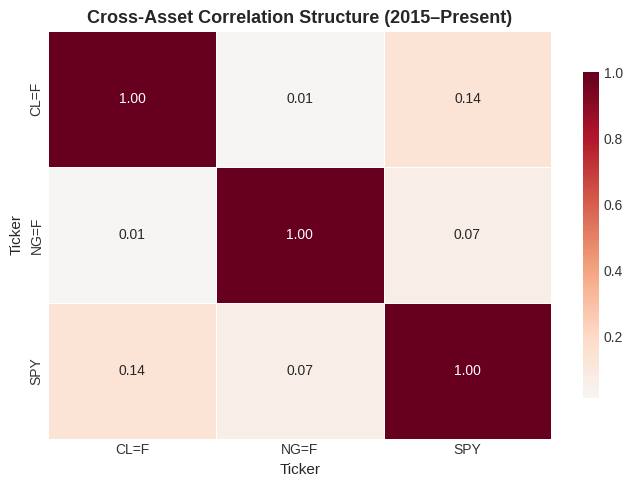

In [122]:
corr = returns.corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size":10}
)

plt.title("Cross-Asset Correlation Structure (2015–Present)", fontsize=13)
plt.tight_layout()
plt.show()

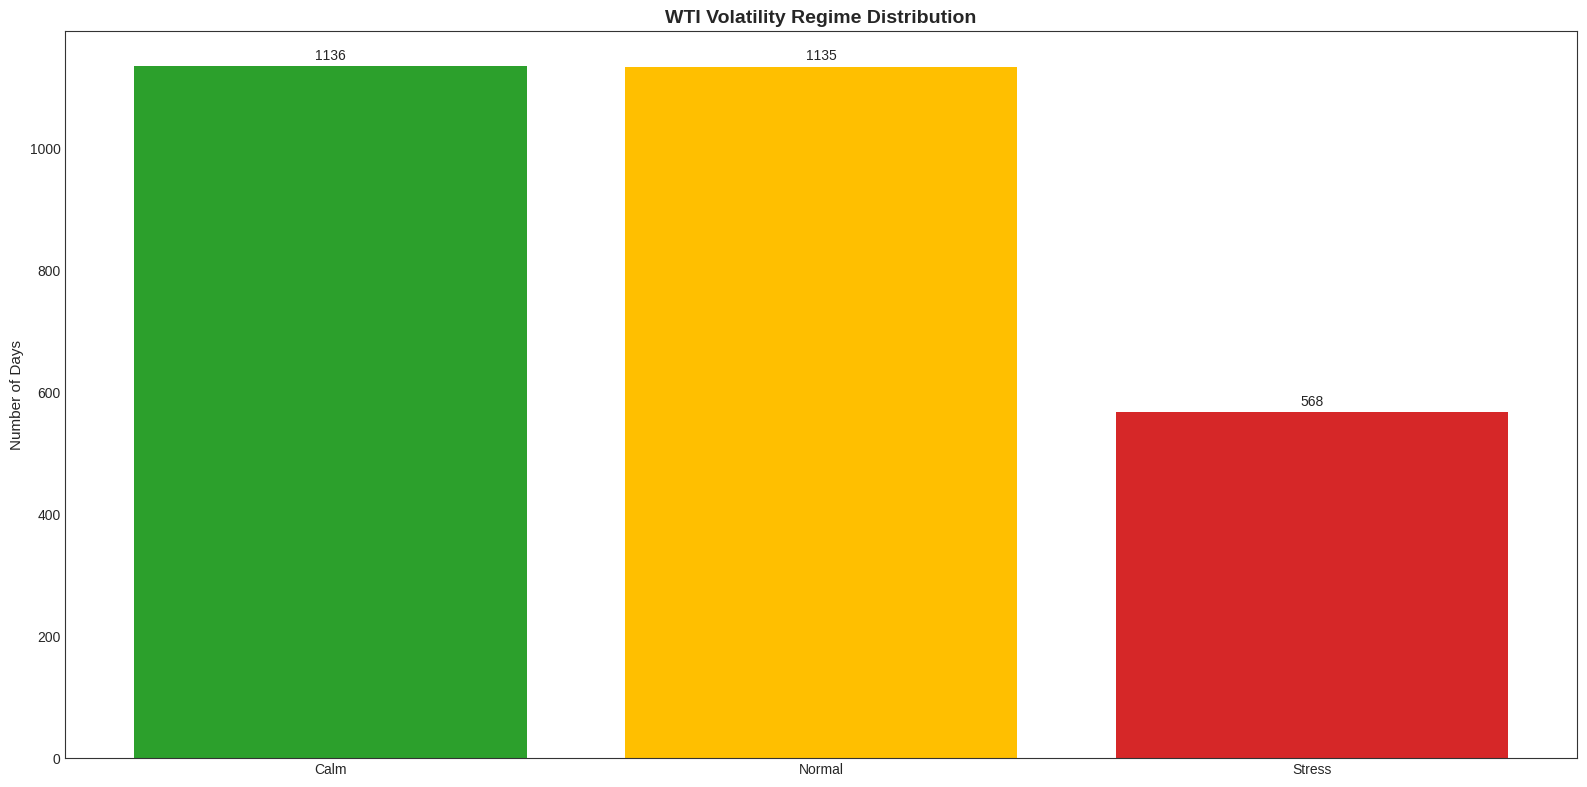

In [113]:
wti_regime = regimes["CL=F"].value_counts().reindex(["Calm", "Normal", "Stress"])

colors = ["#2ca02c", "#ffbf00", "#d62728"]  # green / yellow / red (risk convention)

plt.figure()

plt.bar(wti_regime.index, wti_regime.values, color=colors)

plt.title("WTI Volatility Regime Distribution")
plt.ylabel("Number of Days")

for i, v in enumerate(wti_regime.values):
    plt.text(i, v + 10, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

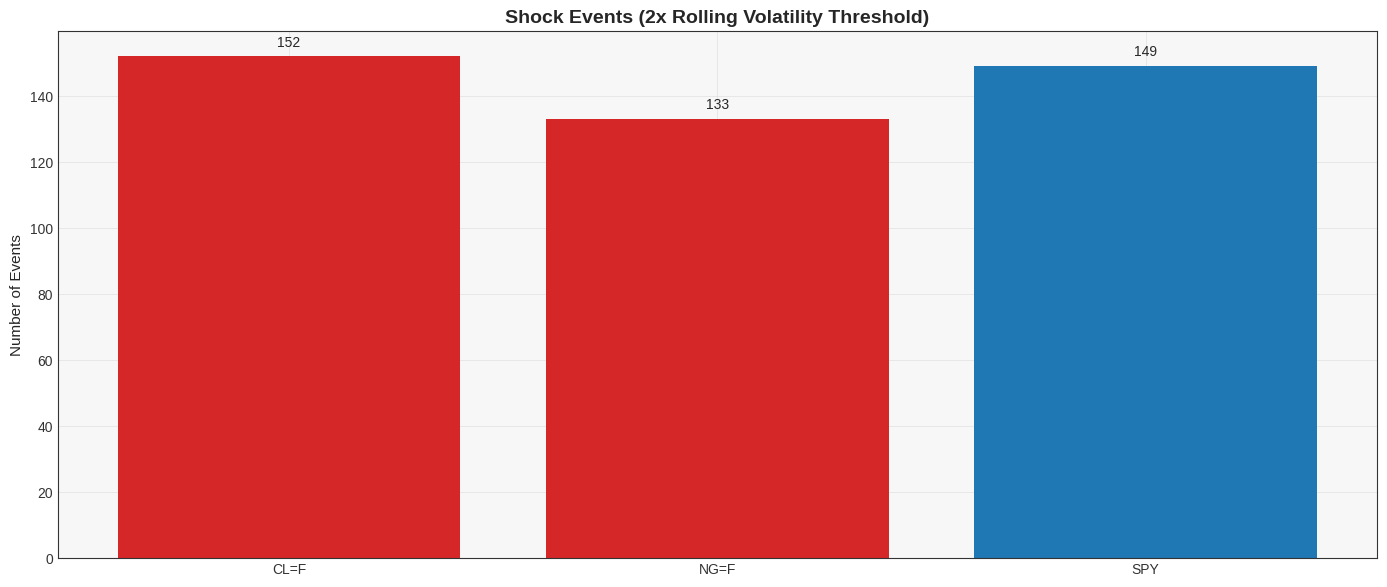

In [124]:
shock_counts = shocks.sum()

colors = ["#d62728", "#d62728", "#1f77b4"]

plt.figure()

plt.bar(shock_counts.index, shock_counts.values, color=colors)

plt.title("Shock Events (2x Rolling Volatility Threshold)")
plt.ylabel("Number of Events")

for i, v in enumerate(shock_counts.values):
    plt.text(i, v + 3, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

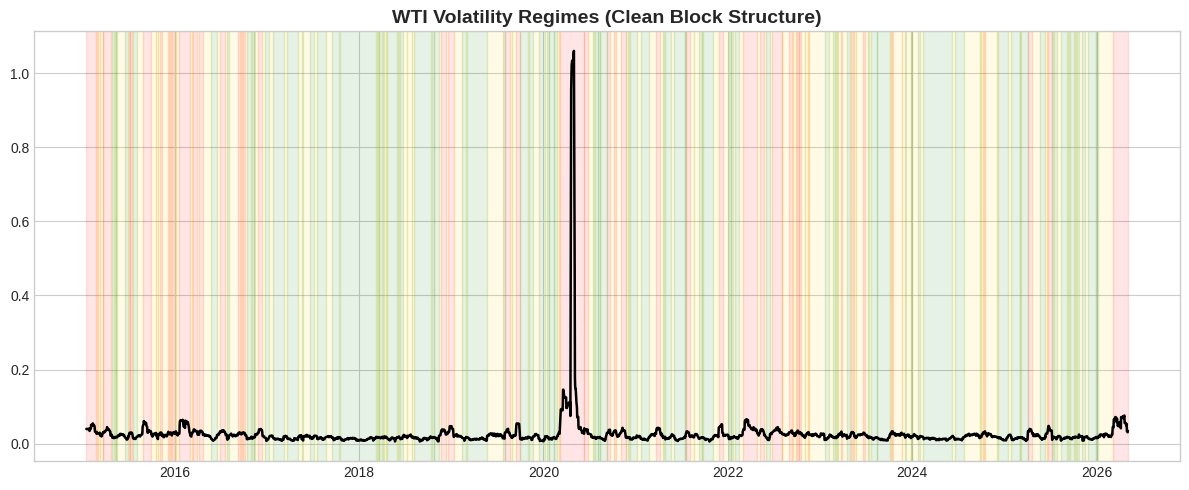

In [94]:
import matplotlib.pyplot as plt

# --- ALIGN DATA PROPERLY ---
vol = vol_10d["CL=F"].dropna()
reg = regimes["CL=F"].reindex(vol.index)

plt.figure(figsize=(12,5))

# --- MAIN LINE ---
plt.plot(vol.index, vol.values, color="black", linewidth=1.8)

# --- BUILD CLEAN REGIME BLOCKS ---
start = vol.index[0]
current = reg.iloc[0]

for i in range(1, len(vol)):

    if reg.iloc[i] != current:
        end = vol.index[i]

        if current == "Calm":
            color = "green"
        elif current == "Normal":
            color = "gold"
        else:
            color = "red"

        plt.axvspan(start, end, color=color, alpha=0.10)

        start = vol.index[i]
        current = reg.iloc[i]

# final segment
if current == "Calm":
    color = "green"
elif current == "Normal":
    color = "gold"
else:
    color = "red"

plt.axvspan(start, vol.index[-1], color=color, alpha=0.10)

plt.title("WTI Volatility Regimes (Clean Block Structure)")
plt.tight_layout()
plt.show()

In [102]:
# CLEAN BLOCK CONSTRUCTION (NO NaT POSSIBLE)

vol = vol_10d["CL=F"]
reg = regimes["CL=F"]

# --- FORCE PERFECT ALIGNMENT ---
df = pd.concat([vol, reg], axis=1)
df.columns = ["vol", "regime"]

# --- DROP ALL BAD ROWS ---
df = df.dropna()

# --- ENSURE INDEX IS DATETIME ---
df.index = pd.to_datetime(df.index)

# --- BUILD CHANGE GROUPS ---
df["change"] = (df["regime"] != df["regime"].shift()).cumsum()

# --- BUILD BLOCKS ---
blocks = (
    df.groupby("change")
    .agg(
        regime=("regime", "first"),
        start=("vol", lambda x: x.index.min()),
        end=("vol", lambda x: x.index.max())
    )
    .reset_index(drop=True)
)

blocks.head()

,regime,start,end
0,Stress,2015-01-16,2015-02-24
1,Normal,2015-02-25,2015-02-25
2,Stress,2015-02-26,2015-02-27
3,Normal,2015-03-02,2015-03-09
4,Stress,2015-03-10,2015-03-10


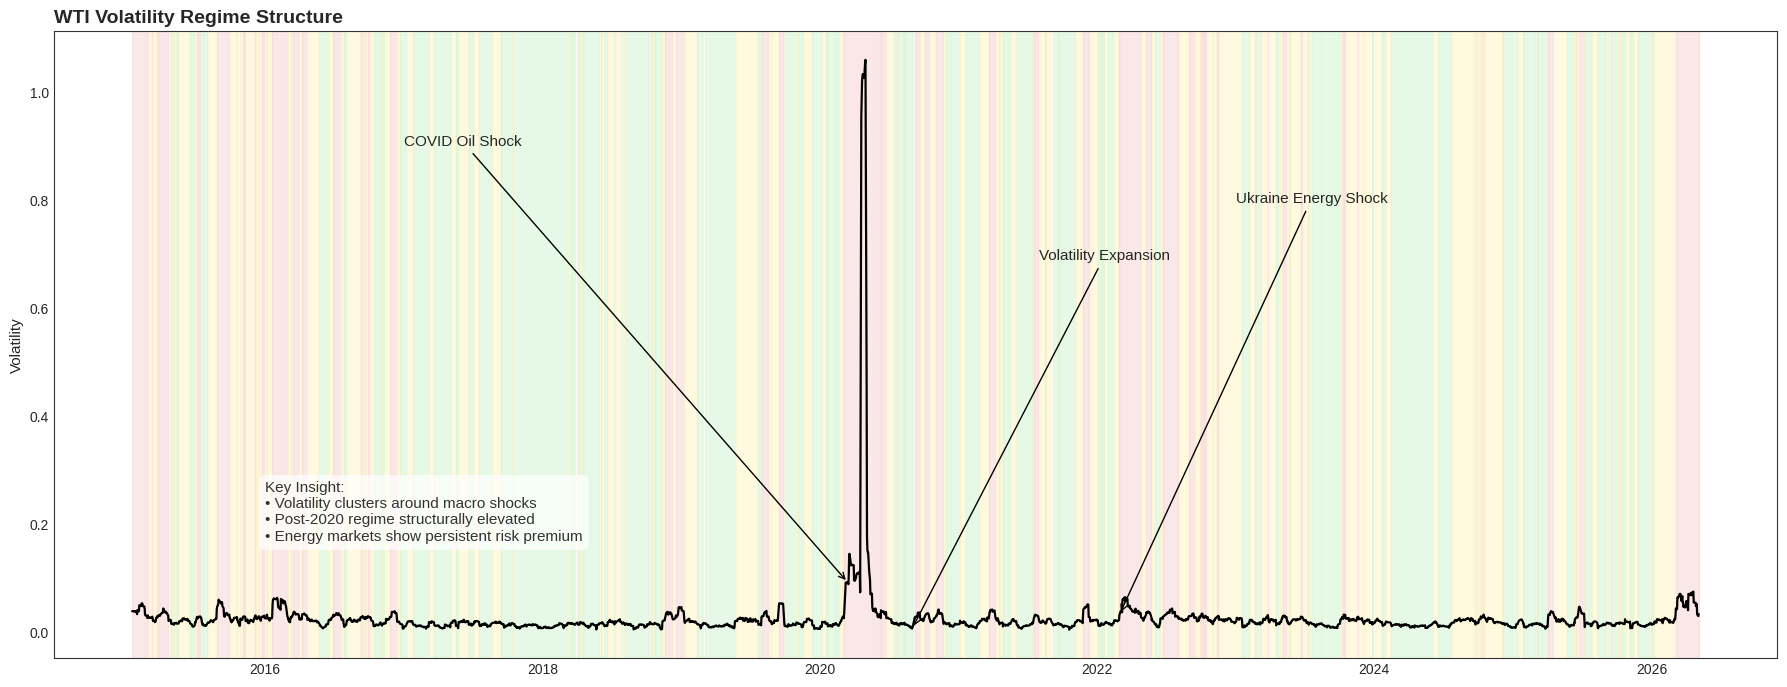

In [119]:
plt.figure(figsize=(18,7))

# -----------------------
# VOLATILITY LINE
# -----------------------
plt.plot(df.index, df["vol"], color="black", linewidth=1.6)

# -----------------------
# REGIME BLOCKS (CLEAN BACKGROUND)
# -----------------------
for _, row in blocks.iterrows():

    if row["regime"] == "Calm":
        color = "#d6f5d6"   # green
    elif row["regime"] == "Normal":
        color = "#fff5cc"   # yellow
    else:
        color = "#f8d7da"   # red

    plt.axvspan(row["start"], row["end"], color=color, alpha=0.6)

# -----------------------
# MACRO EVENT ANNOTATIONS
# -----------------------

plt.annotate(
    "COVID Oil Shock",
    xy=(pd.Timestamp("2020-03-15"), df["vol"].asof(pd.Timestamp("2020-03-15"))),
    xytext=(pd.Timestamp("2017-01-01"), df["vol"].max()*0.85),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.annotate(
    "Volatility Expansion",
    xy=(pd.Timestamp("2020-09-01"), df["vol"].asof(pd.Timestamp("2020-09-01"))),
    xytext=(pd.Timestamp("2021-08-01"), df["vol"].max()*0.65),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.annotate(
    "Ukraine Energy Shock",
    xy=(pd.Timestamp("2022-03-01"), df["vol"].asof(pd.Timestamp("2022-03-01"))),
    xytext=(pd.Timestamp("2023-01-01"), df["vol"].max()*0.75),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

# -----------------------
# INSIGHT BOX (FIXED POSITION)
# -----------------------

plt.text(
    pd.Timestamp("2016-01-01"),
    df["vol"].min() + (df["vol"].max() * 0.15),
    "Key Insight:\n"
    "• Volatility clusters around macro shocks\n"
    "• Post-2020 regime structurally elevated\n"
    "• Energy markets show persistent risk premium",
    fontsize=11,
    color="#333333",
    verticalalignment="bottom",
    bbox=dict(
        facecolor="white",
        alpha=0.7,
        edgecolor="none",
        boxstyle="round,pad=0.4"
    )
)

# -----------------------
# FORMATTING
# -----------------------

plt.title("WTI Volatility Regime Structure", loc="left", fontsize=14, fontweight="bold")
plt.ylabel("Volatility")
plt.grid(False)

plt.tight_layout()
plt.show()

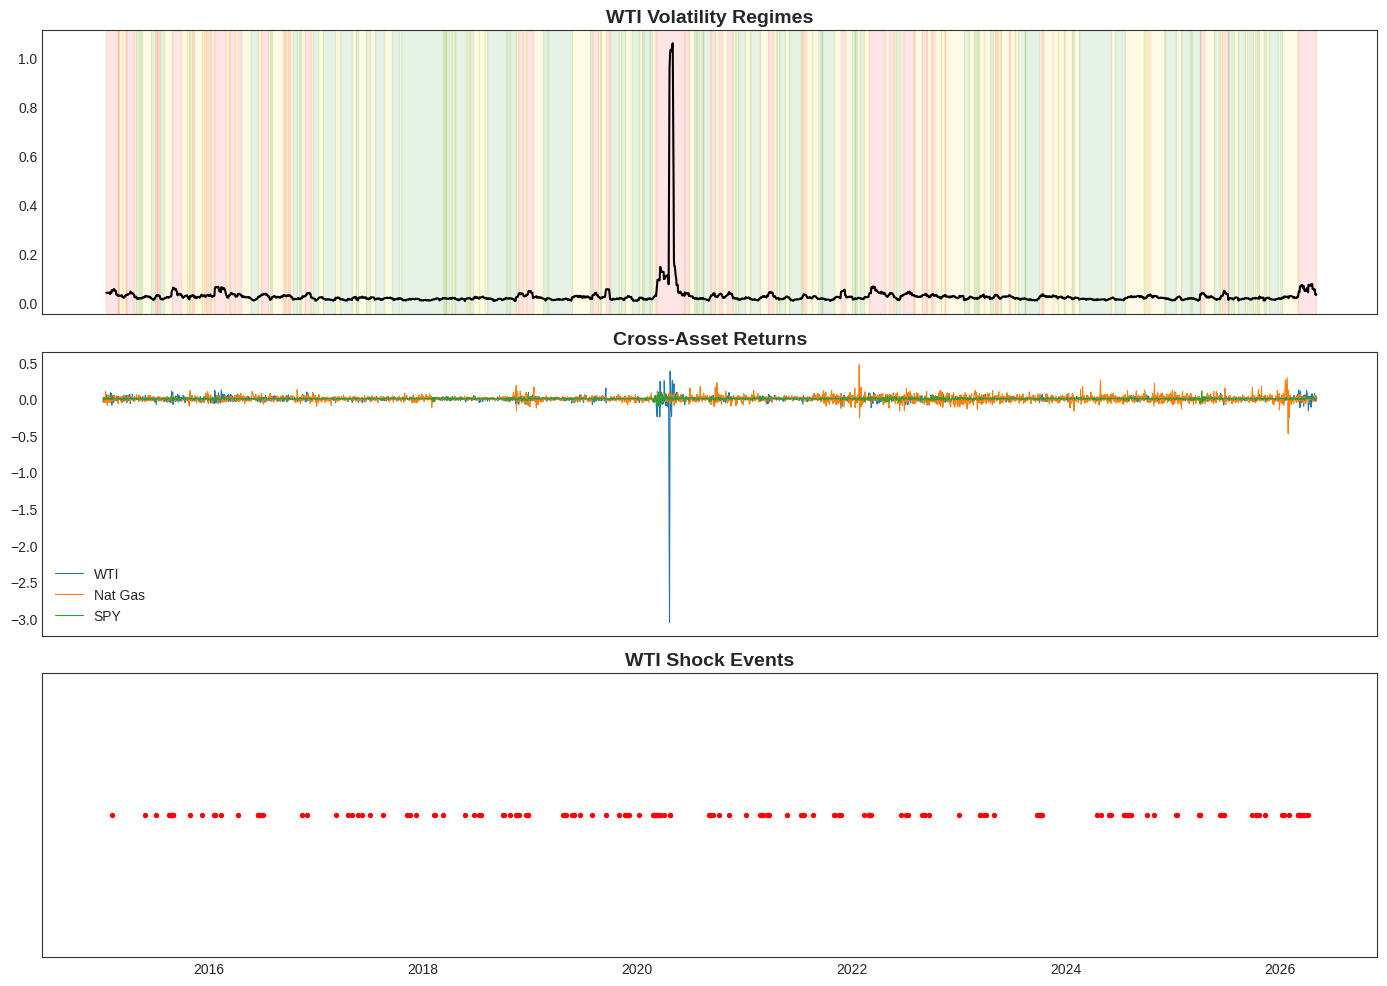

In [115]:
fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

# 1. Volatility + regimes
axes[0].plot(df.index, df["vol"], color="black", linewidth=1.5)

for _, row in blocks.iterrows():
    if row["regime"] == "Calm":
        color = "green"
    elif row["regime"] == "Normal":
        color = "gold"
    else:
        color = "red"

    axes[0].axvspan(row["start"], row["end"], color=color, alpha=0.10)

axes[0].set_title("WTI Volatility Regimes")

# 2. Returns
axes[1].plot(returns["CL=F"], label="WTI", linewidth=0.8)
axes[1].plot(returns["NG=F"], label="Nat Gas", linewidth=0.8)
axes[1].plot(returns["SPY"], label="SPY", linewidth=0.8)
axes[1].legend()
axes[1].set_title("Cross-Asset Returns")

# 3. Shock events
shock_dates = returns.index[shocks["CL=F"]]

axes[2].scatter(shock_dates, [1]*len(shock_dates), color="red", s=8)
axes[2].set_yticks([])
axes[2].set_title("WTI Shock Events")

plt.tight_layout()
plt.show()

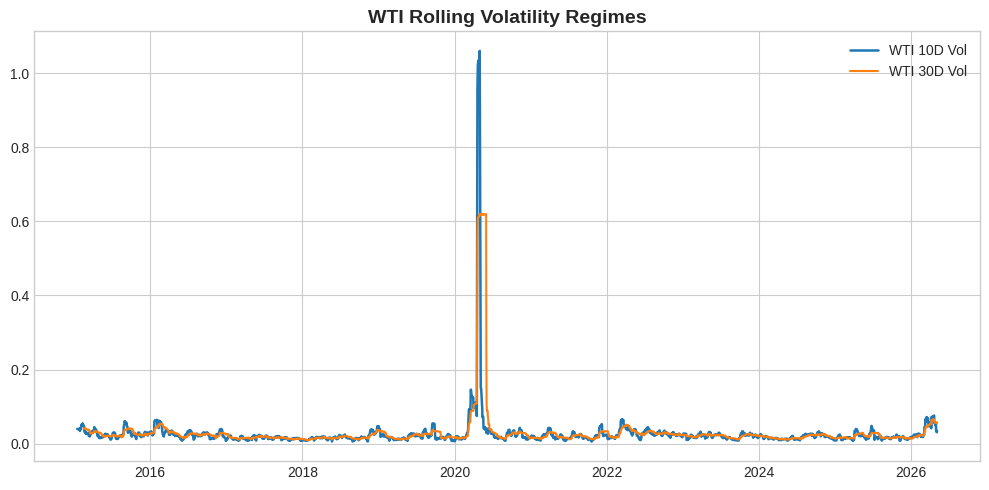

In [95]:
plt.figure()

plt.plot(vol_10d["CL=F"], label="WTI 10D Vol", linewidth=1.8)
plt.plot(vol_30d["CL=F"], label="WTI 30D Vol", linewidth=1.5)

plt.title("WTI Rolling Volatility Regimes")
plt.legend()

plt.tight_layout()
plt.show()

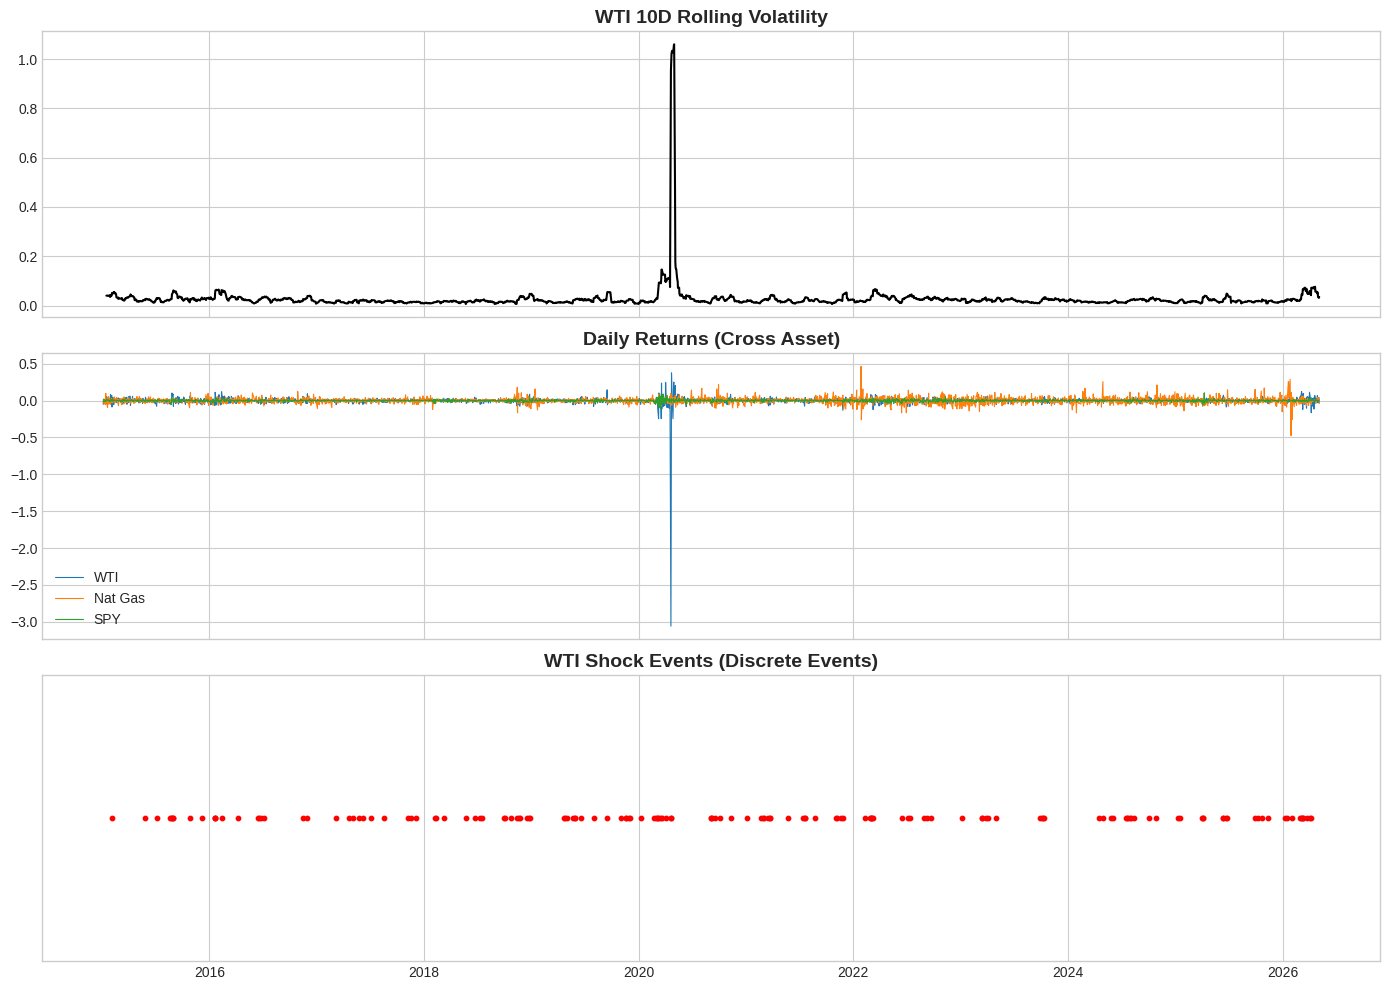

In [90]:
fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

# =========================
# 1. VOLATILITY
# =========================
axes[0].plot(vol_10d["CL=F"], color="black", linewidth=1.5)
axes[0].set_title("WTI 10D Rolling Volatility")

# =========================
# 2. RETURNS
# =========================
axes[1].plot(returns["CL=F"], label="WTI", linewidth=0.8)
axes[1].plot(returns["NG=F"], label="Nat Gas", linewidth=0.8)
axes[1].plot(returns["SPY"], label="SPY", linewidth=0.8)
axes[1].set_title("Daily Returns (Cross Asset)")
axes[1].legend()

# =========================
# 3. SHOCKS (FIXED)
# =========================

shock_dates = returns.index[shocks["CL=F"]]

axes[2].scatter(shock_dates,
                [1]*len(shock_dates),
                color="red",
                s=10)

axes[2].set_title("WTI Shock Events (Discrete Events)")
axes[2].set_yticks([])
axes[2].set_ylim(0.5, 1.5)

plt.tight_layout()
plt.show()

In [81]:
# Align indices (important for correctness)
common_index = returns.index.intersection(regimes.index)

returns_aligned = returns.loc[common_index]
regimes_aligned = regimes.loc[common_index]

stress_mask = regimes_aligned["CL=F"] == "Stress"

print("Correlation during STRESS periods:\n")
print(returns_aligned[stress_mask].corr())

Correlation during STRESS periods:

Ticker      CL=F      NG=F       SPY
Ticker                              
CL=F    1.000000 -0.005213  0.145206
NG=F   -0.005213  1.000000  0.172878
SPY     0.145206  0.172878  1.000000
